# Eight Weeks Without the REM: An Analysis of Open Data

July 5 – August 17, 2025: When the REM suspended service between Brossard and Gare Centrale, the RTL put a shuttle bus network in place for the sake of service continuity. During that downtime, where did the people that relied on the REM go? What did they do instead?

This notebook uses open RTL GTFS data to assess the shuttle system based on stop coverage, frequency, and travel times.


---

## 1. Data setup

In [123]:
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [124]:
# define data paths
DATA_DIR = Path("data")
GTFS_DIR = DATA_DIR / "gtfs"
REM_DIR  = DATA_DIR / "rem"

# create directories for data
for d in [GTFS_DIR, REM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [125]:
def unzip(zip_path: Path) -> None:
    extract_dir = zip_path.with_suffix("")
    if extract_dir.exists():
        print(f"  {extract_dir.name}/ ...already extracted, skipping")
        return
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(extract_dir)
    print(f"  {zip_path.name} → {extract_dir.name}/")

# unzip RTL GTFS
print("RTL GTFS feeds:")
for zp in sorted(GTFS_DIR.glob("*.zip")):
    unzip(zp)

# unzip REM GTFS
print("\nREM GTFS feeds:")
for zp in sorted(REM_DIR.glob("*.zip")):
    unzip(zp)

RTL GTFS feeds:
  20250623/ ...already extracted, skipping
  20250707/ ...already extracted, skipping
  20250825/ ...already extracted, skipping

REM GTFS feeds:
  gtfs/ ...already extracted, skipping


In [126]:
# summarize data after being unzipped

print("RTL GTFS data overview:")
for d in sorted(GTFS_DIR.iterdir()):
    if d.is_dir():
        print(f"  {d.name}: {len(list(d.iterdir()))} files")

print("\nREM GTFS data overview:")
for d in sorted(REM_DIR.iterdir()):
    if d.is_dir():
        print(f"  {d.name}: {len(list(d.iterdir()))} files")

RTL GTFS data overview:
  20250623: 12 files
  20250707: 12 files
  20250825: 12 files

REM GTFS data overview:
  gtfs: 12 files


---

## 2. Establishing a baseline

Before July 5, the REM's Brossard branch connected five stations from the South Shore to downtown in under 25 minutes. This section profiles that service—stop sequence, scheduled travel time, and peak headways—to establish what riders actually lost when service suspended.

*Note: this feed reflects current REM service (June 2026). The automated Brossard branch has been operationally stable since 2023, so I am treating it as representative of pre-closure service levels.*

In [127]:
# load REM GTFS tables directly
REM_GTFS = REM_DIR / "gtfs"
REM_STOPS     = pd.read_csv(REM_GTFS / "stops.txt")
REM_TRIPS     = pd.read_csv(REM_GTFS / "trips.txt")
REM_STOP_TIMES = pd.read_csv(REM_GTFS / "stop_times.txt")
REM_CALENDAR  = pd.read_csv(REM_GTFS / "calendar.txt")

# brossard branch stations, south to north
# note: brossard station uses code RIV in the REM GTFS (legacy naming)
BRANCH_CODES = ["RIV", "DUQ", "PAN", "IDS", "GCT"]
BRANCH_NAMES = {
    "RIV": "Brossard",
    "DUQ": "Du Quartier",
    "PAN": "Panama",
    "IDS": "Île-des-Soeurs",
    "GCT": "Gare Centrale",
}

# specify GTFS stop type: platform-level stops on the branch
# if you don't do this you mix up the data and break headway calculations
branch_stops_df: pd.DataFrame = REM_STOPS[
    REM_STOPS.stop_id.str.contains("QUAI")
    &
    REM_STOPS.stop_id.str.extract(r"_([A-Z]{3})$")[0].isin(BRANCH_CODES)
].copy()

branch_stops_df["station_code"] = branch_stops_df.stop_id.str.extract(r"_([A-Z]{3})$")

print(f"{len(branch_stops_df)} branch platform stops across {branch_stops_df.station_code.nunique()} stations")

11 branch platform stops across 5 stations


In [128]:
# GTFS times can exceed 24:00:00 for post-midnight service
def to_minutes(t: str) -> float:
    h, m, s = map(int, t.split(":"))
    return h * 60 + m + s / 60

# filter stop_times to branch platforms and parse times
branch_st: pd.DataFrame = REM_STOP_TIMES[REM_STOP_TIMES.stop_id.isin(branch_stops_df.stop_id)].copy()

branch_st["station_code"] = branch_st.stop_id.str.extract(r"_([A-Z]{3})$")
branch_st["dep_min"] = branch_st.departure_time.apply(to_minutes)
branch_st["arr_min"] = branch_st.arrival_time.apply(to_minutes)

# candidates: trips serving both Brossard (RIV) and Gare Centrale (GCT)
trips_at_riv = set(branch_st[branch_st.station_code == "RIV"].trip_id)
trips_at_gct = set(branch_st[branch_st.station_code == "GCT"].trip_id)
candidates: pd.DataFrame = branch_st[branch_st.trip_id.isin(trips_at_riv & trips_at_gct)]

# northbound trips: Brossard stop_sequence < Gare Centrale stop_sequence
riv_seq = candidates[candidates.station_code == "RIV"].groupby("trip_id")["stop_sequence"].min()
gct_seq = candidates[candidates.station_code == "GCT"].groupby("trip_id")["stop_sequence"].min()

northbound_ids = riv_seq[riv_seq < gct_seq].index

print(f"Northbound trips identified: {len(northbound_ids)}")

nb_st = branch_st[branch_st.trip_id.isin(northbound_ids)].copy()

# elapsed time from brossard departure (origin stop is 0.0)
riv_dep = nb_st[nb_st.station_code == "RIV"].groupby("trip_id")["dep_min"].min()
nb_st["elapsed"] = nb_st["arr_min"] - nb_st.trip_id.map(riv_dep)
nb_st.loc[nb_st.station_code == "RIV", "elapsed"] = 0.0

# median elapsed time at each station across all northbound trips
profile: pd.DataFrame = (
    nb_st
    .groupby("station_code")["elapsed"]
    .median()
    .reindex(BRANCH_CODES)
    .reset_index()
    .rename(columns={"elapsed": "min_from_brossard"})
)

profile["station"] = profile.station_code.map(BRANCH_NAMES)
profile["min_from_brossard"] = profile.min_from_brossard.round(1)

print()
print(profile[["station", "min_from_brossard"]].to_string(index=False))

Northbound trips identified: 536

       station  min_from_brossard
      Brossard                0.0
   Du Quartier                2.0
        Panama                5.7
Île-des-Soeurs               10.6
 Gare Centrale               17.8


In [129]:
# weekday service IDs from calendar
weekday_service_ids = REM_CALENDAR[REM_CALENDAR.monday == 1].service_id
weekday_trip_ids = REM_TRIPS[REM_TRIPS.service_id.isin(weekday_service_ids)].trip_id

# northbound weekday departures from brossard, sorted chronologically
brossard_deps: pd.DataFrame = (
    nb_st[
        nb_st.trip_id.isin(weekday_trip_ids) &
        (nb_st.station_code == "RIV")
    ]
    .drop_duplicates(subset=["trip_id"])
    .sort_values("dep_min")
    .copy()
)

brossard_deps["headway_min"] = brossard_deps.dep_min.diff()

# all-day (5am–11pm) and morning peak (7–9am)
allday = brossard_deps[brossard_deps.dep_min.between(5 * 60, 23 * 60)]
peak   = brossard_deps[brossard_deps.dep_min.between(7 * 60,  9 * 60)]

print("Weekday headways at Brossard (northbound):")
print(f"  All-day median:        {allday.headway_min.median():.1f} min")
print(f"  Morning peak median:   {peak.headway_min.median():.1f} min")
print(f"  Morning peak min:      {peak.headway_min.min():.1f} min")

Weekday headways at Brossard (northbound):
  All-day median:        3.5 min
  Morning peak median:   3.5 min
  Morning peak min:      3.5 min


---

## 3. The analysis part

Displaced South Shore riders had two realistic transit paths downtown:

**The express path:** Route 722 (Panama →  Terminus Centre-Ville) runs the same corridor as the REM's Brossard branch via the Champlain Bridge. This is the most direct path.

**The metro path:** A local bus to Terminus Longueuil (Longueuil–Université-de-Sherbrooke, Yellow Line), then metro to Berri-UQAM and onward. Slower and requiring a transfer, but using established infrastructure not subject to Champlain Bridge traffic.

This section profiles both main paths and asks whether the RTL anticipated demand for either.

In [130]:
# load RTL GTFS tables for both periods
def load_rtl(snapshot: str) -> dict:
    path = GTFS_DIR / snapshot
    return {
        "routes":     pd.read_csv(path / "routes.txt"),
        "trips":      pd.read_csv(path / "trips.txt"),
        "stop_times": pd.read_csv(path / "stop_times.txt"),
        "stops":      pd.read_csv(path / "stops.txt"),
        "calendar":   pd.read_csv(path / "calendar.txt"),
    }

# baseline, during closure, post closure
BASELINE: dict = load_rtl("20250623")
DURING: dict  = load_rtl("20250707")
POST: dict = load_rtl("20250825")

# terminus panama stop IDs (the formal REM bus terminal only, not the street stops around)
# note that if stop IDs changed btwn feeds, the during closure and post closure profiles would quietly miss stops
terminus_panama_ids = BASELINE["stops"][BASELINE["stops"].stop_name == "Terminus Panama"].stop_id

print(f"Terminus Panama stop IDs: {terminus_panama_ids.tolist()}")

Terminus Panama stop IDs: [3492, 4429, 5923, 5925, 5927]


In [131]:
def profile_722(feed: dict, label: str) -> pd.Series:
    r722_id = feed["routes"][feed["routes"].route_short_name == "722"].route_id.iloc[0]

    weekday_sids = feed["calendar"][feed["calendar"].monday == 1].service_id

    weekday_722 = feed["trips"][
        (feed["trips"].route_id == r722_id) &
        feed["trips"].service_id.isin(weekday_sids)
    ].trip_id

    max_seq = feed["stop_times"][feed["stop_times"].trip_id.isin(weekday_722)].groupby("trip_id")["stop_sequence"].max()

    panama_st = feed["stop_times"][
        feed["stop_times"].trip_id.isin(weekday_722) &
        feed["stop_times"].stop_id.isin(terminus_panama_ids)
    ].copy()
    panama_st = panama_st[panama_st.stop_sequence < panama_st.trip_id.map(max_seq)]
    panama_st["dep_min"] = panama_st.departure_time.apply(to_minutes)
    panama_st = panama_st.sort_values("dep_min").drop_duplicates(subset=["trip_id"])
    panama_st["headway"] = panama_st.dep_min.diff()

    allday = panama_st[panama_st.dep_min.between(5 * 60, 23 * 60)]
    peak   = panama_st[panama_st.dep_min.between(7 * 60,  9 * 60)]

    return pd.Series({
        "period":              label,
        "weekday_trips":       len(panama_st),
        "allday_headway_med":  round(allday.headway.median(), 1),
        "peak_headway_med":    round(peak.headway.median(), 1),
    })

rows = [
    profile_722(BASELINE, "Baseline (Jun 23)"),
    profile_722(DURING, "Closure (Jul 7)")
]

summary_722 = pd.DataFrame(rows).set_index("period")

print("Route 722: Panama northbound, weekdays")
print(summary_722.to_string())

Route 722: Panama northbound, weekdays
                   weekday_trips  allday_headway_med  peak_headway_med
period                                                                
Baseline (Jun 23)             27                10.0               NaN
Closure (Jul 7)              183                 4.0               2.0


In [132]:
# travel time: median trip duration from terminus panama to terminus centre-ville
r722_id = DURING["routes"][DURING["routes"].route_short_name == "722"].route_id.iloc[0]
weekday_sids = DURING["calendar"][DURING["calendar"].monday == 1].service_id

# direction 1 = northbound (panama →  centre-ville)
weekday_722_nb = DURING["trips"][
    (DURING["trips"].route_id == r722_id) &
    DURING["trips"].service_id.isin(weekday_sids) &
    (DURING["trips"].direction_id == 1)
].trip_id

terminus_cv_ids = DURING["stops"][DURING["stops"].stop_name == "Terminus Centre-Ville"].stop_id

st_722_nb = DURING["stop_times"][DURING["stop_times"].trip_id.isin(weekday_722_nb)].copy()

st_722_nb["dep_min"] = st_722_nb.departure_time.apply(to_minutes)
st_722_nb["arr_min"] = st_722_nb.arrival_time.apply(to_minutes)

panama_dep = st_722_nb[st_722_nb.stop_id.isin(terminus_panama_ids)].groupby("trip_id")["dep_min"].min()
cv_arr     = st_722_nb[st_722_nb.stop_id.isin(terminus_cv_ids)].groupby("trip_id")["arr_min"].max()

travel_times = (cv_arr - panama_dep).dropna()

print(f"Route 722 travel time, Panama →  Centre-Ville (weekday northbound):")
print(f"  Median: {travel_times.median():.1f} min")
print(f"  Range:  {travel_times.min():.0f}-{travel_times.max():.0f} min")
print()

# summary comparison
print("─" * 46)
print(f"{'':25} {'REM':>8}  {'722':>8}")
print("─" * 46)
print(f"{'Travel time (min)':25} {'17.8':>8}  {travel_times.median():>8.1f}")
print(f"{'All-day headway (min)':25} {'3.5':>8}  {summary_722.loc['Closure (Jul 7)', 'allday_headway_med']:>8.1f}")
print(f"{'Peak headway (min)':25} {'3.5':>8}  {summary_722.loc['Closure (Jul 7)', 'peak_headway_med']:>8.1f}")
print("─" * 46)

Route 722 travel time, Panama →  Centre-Ville (weekday northbound):
  Median: 24.0 min
  Range:  16-27 min

──────────────────────────────────────────────
                               REM       722
──────────────────────────────────────────────
Travel time (min)             17.8      24.0
All-day headway (min)          3.5       4.0
Peak headway (min)             3.5       2.0
──────────────────────────────────────────────


### The yellow line "bypass"

Route 722 wasn't the only way to get downtown. A rider at Panama station could instead take a local bus to Terminus Longueuil (the Yellow Line metro station), then ride the metro to Berri-UQAM and connect from there. This is admittedly a bit counter-intuitive, slower and requiring a transfer, but using infrastructure that was already running and not subject to Champlain Bridge traffic. It might speak to those who have to take the metro line as far as Laval, for instance. 

If RTL anticipated demand for this path, we'd expect to see increased frequency on the routes that feed Terminus Longueuil from the south. The GTFS makes that decision visible.

This section explores Terminus Longueuil bus service frequency. 

In [133]:
# Terminus Longueuil = Longueuil–Université-de-Sherbrooke metro station (Yellow Line)
terminus_longueuil_ids_baseline = BASELINE["stops"][BASELINE["stops"].stop_name == "Terminus Longueuil"].stop_id
terminus_longueuil_ids_during  = DURING["stops"][DURING["stops"].stop_name  == "Terminus Longueuil"].stop_id

def weekday_trips_at(feed, term_ids):
    weekday_sid = feed["calendar"][feed["calendar"].monday == 1].service_id
    weekday_trip_ids = feed["trips"][feed["trips"].service_id.isin(weekday_sid)].trip_id
    trips_at = feed["stop_times"][
        feed["stop_times"].stop_id.isin(term_ids)
        &
        feed["stop_times"].trip_id.isin(weekday_trip_ids)
    ].trip_id.unique()
    return (
        feed["trips"][feed["trips"].trip_id.isin(trips_at)]
        .merge(feed["routes"][["route_id", "route_short_name"]], on="route_id")
        .groupby("route_short_name")["trip_id"]
        .nunique()
    )

longueuil_baseline = weekday_trips_at(BASELINE, terminus_longueuil_ids_baseline)
longueuil_during  = weekday_trips_at(DURING,  terminus_longueuil_ids_during)

compare = pd.concat([longueuil_baseline.rename("baseline"), longueuil_during.rename("closure")], axis=1).fillna(0).astype(int)
compare["delta"] = compare["closure"] - compare["baseline"]

changed = compare[compare["delta"] != 0]

print(f"Routes serving Terminus Longueuil (Yellow Line): {len(compare)}")
print(f"Routes with changed weekday trip count during closure: {len(changed)}")
print()
print(f"Total weekday trips baseline: {compare.baseline.sum():,}")
print(f"Total weekday trips closure:  {compare.closure.sum():,}")
print(f"Delta:                        {compare.delta.sum():+,}")


Routes serving Terminus Longueuil (Yellow Line): 46
Routes with changed weekday trip count during closure: 0

Total weekday trips baseline: 2,611
Total weekday trips closure:  2,611
Delta:                        +0


### Routes 720 and 721: inspired by rider insights gained from the REM closure?

The post-closure GTFS data feed (August 25, after REM service restored) introduces two routes that didn't exist before the closure:

- **Route 720**: Brossard / Du Quartier / Panama / Île-des-Soeurs
- **Route 721**: Brossard / Du Quartier / Gare Centrale

Route 721 is especially interesting: it is a direct express line from Brossard to Gare Centrale with a stop at Du Quartier, effectively making it a bus shadow of the REM's own stop pattern. Whether this was planned independently or prompted by the closure experience, the GTFS records it as an addition to the network that wasn't there before.

This section explores these data outliers.


In [134]:
new_routes = ["720", "721"]

for rname in new_routes:
    r = POST["routes"][POST["routes"].route_short_name == rname].iloc[0]

    weekday_sids = POST["calendar"][POST["calendar"].monday == 1].service_id

    trips = POST["trips"][
        (POST["trips"].route_id == r.route_id)
        &
        POST["trips"].service_id.isin(weekday_sids)
    ]

    stops_on_route = (
        POST["stop_times"][POST["stop_times"].trip_id.isin(trips.trip_id)]
        .merge(POST["stops"][["stop_id", "stop_name"]], on="stop_id")
        .groupby("stop_sequence")["stop_name"].first()
        .sort_index()
    )

    print(f"Route {rname}: {r.route_long_name}")
    print(f"  Weekday trips: {len(trips)}")
    print(f"  Stops: {' →  '.join(stops_on_route.unique())}")
    print()

Route 720: Brossard / Du Quartier / Panama / Île-des-Soeurs
  Weekday trips: 20
  Stops: Station Île-des-Soeurs →  du Quartier / du Square →  du Quartier / de l'Équinoxe →  Terminus Panama →  Leduc / du Quartier →  Terminus Brossard

Route 721: Brossard / Du Quartier / Gare centrale
  Weekday trips: 62
  Stops: Terminus Brossard →  du Quartier / du Square →  du Quartier / de l'Équinoxe →  Leduc / du Quartier →  800 De La Gauchetière O.



### The feeder buses to Panama station

Route 722 picks up at Panama station, not at Brossard station. For riders who were in Brossard and couldn't walk to Panama, getting to route 722 required a transfer: first take route 38 (Terminus Brossard →  Terminus Panama), then board 722 onward.

The REM's Brossard station had served the Brossard population directly. With it closed, it gets complicated for riders. If the RTL left route 38 unchanged, the impressive 2-minute peak headway of the 722 would risk feeling irrelevant to riders.

This section analyzes route 38 as an example of a feeder bus to the Panama REM station.

In [135]:
def profile_route(feed: dict, label: str, rname: str) -> pd.Series:
    r = feed["routes"][feed["routes"].route_short_name.astype(str) == rname].iloc[0]

    weekday_sid = feed["calendar"][feed["calendar"].monday == 1].service_id
    weekday_trips = feed["trips"][
        (feed["trips"].route_id == r.route_id) &
        feed["trips"].service_id.isin(weekday_sid)
    ].trip_id

    stop_times = feed["stop_times"][feed["stop_times"].trip_id.isin(weekday_trips)].copy()
    stop_times["dep_min"] = stop_times.departure_time.apply(to_minutes)

    first_deps = stop_times.sort_values("stop_sequence").groupby("trip_id")["dep_min"].first().sort_values()

    # all-day headway
    allday_hw = first_deps[first_deps.between(5*60, 23*60)].diff().median()

    return pd.Series({
        "period":        label,
        "weekday_trips": len(weekday_trips),
        "allday_headway_med": round(allday_hw, 1),
    })

rows = [
    profile_route(BASELINE, "Baseline (Jun 23)", "38"),
    profile_route(DURING,  "Closure (Jul 7)",   "38"),
    profile_route(POST, "Post (Aug 25)",      "38"),
]

route_38_df = pd.DataFrame(rows).set_index("period")

# route 38 headway
route_38_hw = route_38_df.loc['Closure (Jul 7)','allday_headway_med'].item()

print("Route 38: Terminus Brossard →  Terminus Panama")
print(route_38_df.to_string())
print()
print("Route 722 peak headway during closure: 2.0 min")
print(f"Route 38 headway throughout:          {route_38_hw:.1f} min")


Route 38: Terminus Brossard →  Terminus Panama
                   weekday_trips  allday_headway_med
period                                              
Baseline (Jun 23)             62                17.0
Closure (Jul 7)               62                17.0
Post (Aug 25)                 62                17.0

Route 722 peak headway during closure: 2.0 min
Route 38 headway throughout:          17.0 min


### A quick visual comparison of headways during the closure

The bar graph below captures headway data from the 722: before the closure, during and after. The 722 normally doesn't operate enough to be a peak service; that job is left to the REM. During the closure, the 722 took on peak times instead of the REM.  

For comparison's sake, route 38 (a feeder bus to Panama station, where you catch the 722) headways are shown in dashed red lines. The scheduled headways did not change the entire summer, even with the closure in effect. 

> *note that lower headways indicate higher bus frequency*

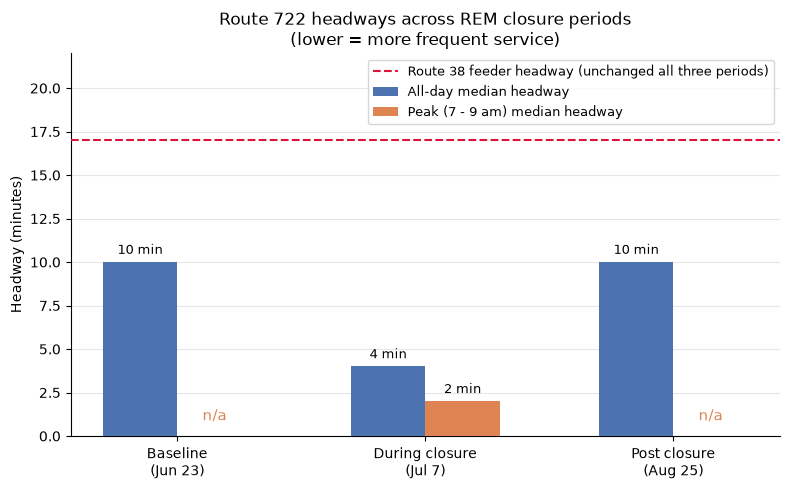

In [136]:
post_722_row = profile_722(POST, "Post (Aug 25)")
summary_722_all = pd.concat([summary_722, post_722_row.to_frame().T.set_index("period")])

periods  = ["Baseline\n(Jun 23)", "During closure\n(Jul 7)", "Post closure\n(Aug 25)"]
allday   = list(summary_722_all["allday_headway_med"])
peak_raw = list(summary_722_all["peak_headway_med"])   # NaN for baseline

x = np.arange(len(periods)) # bar centre positions
w = 0.30 # bar widths

fig, ax = plt.subplots(figsize=(8, 5))

bars_allday = ax.bar(x - w / 2, allday, w, label="All-day median headway",
                     color="#4C72B0", zorder=3)
peak_vals   = [v if not np.isnan(v) else 0 for v in peak_raw]
bars_peak   = ax.bar(x + w / 2, peak_vals, w, label="Peak (7 - 9 am) median headway",
                     color="#DD8452", zorder=3)

# route 38 feeder reference line
ax.axhline(17.0, color="crimson", linestyle="--", linewidth=1.5, zorder=4,
           label="Route 38 feeder headway (unchanged all three periods)")

# value labels
for bar, val in zip(bars_allday, allday):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f"{val:.0f} min", ha="center", va="bottom", fontsize=9)
for bar, val in zip(bars_peak, peak_raw):
    if np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, 0.7,
                "n/a", ha="center", va="bottom", fontsize=11, color="#DD8452")
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f"{val:.0f} min", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Headway (minutes)")
ax.set_title("Route 722 headways across REM closure periods\n(lower = more frequent service)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.set_ylim(0, 22)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

---

## 4. What the data can and can't tell us

### Some conclusions

The GTFS feeds tell a clear operational story: 
- The RTL boosted route 722 from 27 to 183 northbound weekday trips during the closure: a 578% increase. 
- The established schedule delivered roughly comparable frequency to the REM (4-minute all-day headway, 2-minute peak). 
- The scheduled travel time was 35% longer (24 min vs. 18 min), but the service to get across the river existed and it was dense.
- However: people who originally rode from Brossard were likely the biggest casualties, as it appears the RTL did not add service to an important Panama feeder line (Route 38), making the low headways of the 722 largely irrelevant. Basically, if you lived close to the Brossard REM station and not the Panama station, your commute was likely much longer regardless of the relatively-efficient 722 (as you would have to get to Panama first to take the 722).

However, this is just how the RTL responded, not what people actually did to circumvent the downtime. 

After some research regarding the presences of routes 720 and 721: they are special express buses that are only in operation as needed. They must have been responding to a need at the end of the closure, but these routes are effectively noise when it comes to our problem statement. 

---

### Operational vs. behavioural

GTFS data captures what RTL *scheduled*, not what riders *experienced*: only the operational question can be answered. The more interesting stuff—what humans do instead when there is discontinuation of an important transit channel—is all behavioural and requires anonymised user data. 

During a major rail closure, route 722 buses share the Champlain Bridge corridor with everyone who would otherwise have been on the REM. Traffic variance, bunching, and crowding are invisible in the feed. 

The frequency boost confirms RTL *anticipated* demand—a meaningful finding about planning intent, especially considering how new the REM is. Once again, it says nothing about whether the buses ran full, whether riders showed up, or whether the service actually absorbed displaced ridership.

---

### Why the behavioural question can't be answered with open data

The deeper question—as in, where did the people who relied on the REM actually go?—is not answerable from this side of the river. 
Open data sources that could plausibly carry a behavioural signal (Bixi, for instance) operate largely on the island. 
The disrupted population was in Brossard (which doesn't have full Bixi service anyways, and even if it did, who is going to commute via Bixi from Brossard?). 
Ultimately, any potential signal would need to be observed at the point of departure, not arrival, and no open dataset does that.

| Question | Better data |
|---|---|
| Did riders actually use route 722? | RTL automated passenger counts (APC) on route 722 |
| How many REM riders were displaced? | ARTM/REM fare gate counts at Brossard, before and during |
| Where did they go instead? | Anonymised trip plan data |
| Did driving increase? | Bridge toll or count data on the Champlain corridor |
